# Chapter 25: Utilization Monitoring and Capacity Management

This notebook demonstrates how to monitor equipment utilization across a process train
at different operating points. By running the process at various feed rates and recording
utilization, we can identify when bottleneck transitions occur — the point where a different
equipment item becomes the limiting factor.

**Key Concepts:**
- Equipment utilization at multiple operating points
- Heatmap visualization of utilization matrix
- Bottleneck transition analysis
- Capacity management strategies

In [1]:
# Execute against the selected, compiled NeqSim source checkout.
import os
import sys
from pathlib import Path
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import jpype

if not os.environ.get("NEQSIM_PROJECT_ROOT"):
    raise RuntimeError("Set NEQSIM_PROJECT_ROOT to the NeqSim source checkout before running.")
PROJECT_ROOT = Path(os.environ["NEQSIM_PROJECT_ROOT"]).resolve()
if not (PROJECT_ROOT / "devtools" / "neqsim_dev_setup.py").exists():
    raise RuntimeError("NEQSIM_PROJECT_ROOT must contain devtools/neqsim_dev_setup.py.")
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes
ns = neqsim_classes(neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=False))
jneqsim = jpype.JPackage("neqsim")
NEQSIM_MODE = "devtools"
NOTEBOOK_PATH = Path(globals().get("__vsc_ipynb_file__", Path.cwd() / "ch26_utilization_monitoring.ipynb")).resolve()
BOOK_ROOT = NOTEBOOK_PATH.parents[3]
FIGURES_DIR = NOTEBOOK_PATH.parent.parent / "figures"
FIGURES_DIR.mkdir(exist_ok=True)
sys.path.insert(0, str(BOOK_ROOT / "devtools"))
from book_figure_tools import configure_figures, export_figure_summary
configure_figures()
print(f"NeqSim source: {PROJECT_ROOT}; Python: {sys.executable}")

# Named NeqSim class bindings used throughout the chapter.
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
SystemPrEos = jneqsim.thermo.system.SystemPrEos
SystemSrkCPAstatoil = jneqsim.thermo.system.SystemSrkCPAstatoil
ThermodynamicOperations = jneqsim.thermodynamicoperations.ThermodynamicOperations
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ThreePhaseSeparator = jneqsim.process.equipment.separator.ThreePhaseSeparator
Compressor = jneqsim.process.equipment.compressor.Compressor
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Heater = jneqsim.process.equipment.heatexchanger.Heater
HeatExchanger = jneqsim.process.equipment.heatexchanger.HeatExchanger
Mixer = jneqsim.process.equipment.mixer.Mixer
Splitter = jneqsim.process.equipment.splitter.Splitter
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Pump = jneqsim.process.equipment.pump.Pump
Expander = jneqsim.process.equipment.expander.Expander
Recycle = jneqsim.process.equipment.util.Recycle
ProcessSystem = jneqsim.process.processmodel.ProcessSystem

# Physical verification uses the same model state, source and interpreter.
sys.path.insert(0, str(BOOK_ROOT / "verification" / "scientific_revision"))
from notebook_physics_checks import PhysicsChecks
_physics = PhysicsChecks(NOTEBOOK_PATH)


All NeqSim classes imported OK
NeqSim source: C:\Users\solbraa\OneDrive - NTNU\Documents\ChatGPT\NeqSim; Python: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe


## 25.1 Build a Multi-Equipment Process

We build a gas processing train with several equipment items, each with its own capacity constraint:
- HP separator (gas throughput limit)
- 1st stage compressor (power limit)
- Inter-stage cooler (duty limit)
- 2nd stage compressor (power limit)
- Export cooler

In [2]:
# jneqsim is bound to the source JVM in the setup cell.

# --- Fluid ---
fluid = jneqsim.thermo.system.SystemSrkEos(273.15 + 30.0, 55.0)
fluid.addComponent("nitrogen", 0.01)
fluid.addComponent("CO2", 0.02)
fluid.addComponent("methane", 0.82)
fluid.addComponent("ethane", 0.07)
fluid.addComponent("propane", 0.04)
fluid.addComponent("n-butane", 0.02)
fluid.addComponent("n-pentane", 0.01)
fluid.addComponent("n-hexane", 0.01)
fluid.setMixingRule("classic")

# --- Design rate: 60000 kg/hr ---
design_rate = 60000.0  # kg/hr

feed = jneqsim.process.equipment.stream.Stream("Feed Gas", fluid)
feed.setFlowRate(design_rate, "kg/hr")
feed.setTemperature(30.0, "C")
feed.setPressure(55.0, "bara")

separator = jneqsim.process.equipment.separator.Separator("HP Separator", feed)

comp1 = jneqsim.process.equipment.compressor.Compressor("Compressor Stage 1", separator.getGasOutStream())
comp1.setOutletPressure(95.0)
# comp1.setMaximumPower(3500.0)  # kW  # Method not available in NeqSim

cooler1 = jneqsim.process.equipment.heatexchanger.Cooler("Inter-stage Cooler", comp1.getOutletStream())
cooler1.setOutTemperature(273.15 + 35.0)

comp2 = jneqsim.process.equipment.compressor.Compressor("Compressor Stage 2", cooler1.getOutletStream())
comp2.setOutletPressure(170.0)
# comp2.setMaximumPower(4000.0)  # kW  # Method not available in NeqSim

cooler2 = jneqsim.process.equipment.heatexchanger.Cooler("Export Cooler", comp2.getOutletStream())
cooler2.setOutTemperature(273.15 + 40.0)

process = jneqsim.process.processmodel.ProcessSystem()
process.add(feed)
process.add(separator)
process.add(comp1)
process.add(cooler1)
process.add(comp2)
process.add(cooler2)
process.run()
assert _physics.run(process, 'calculation_cell_3:process', candidate=False)

print(f"Design rate: {design_rate:.0f} kg/hr")
print(f"Comp1 power: {comp1.getPower('kW'):.1f} kW (max: 3500 kW)")
print(f"Comp2 power: {comp2.getPower('kW'):.1f} kW (max: 4000 kW)")


Design rate: 60000 kg/hr
Comp1 power: 998.7 kW (max: 3500 kW)
Comp2 power: 1037.5 kW (max: 4000 kW)


## 25.2 Utilization at Different Operating Points

We run the process at 50%, 75%, 100%, 110%, and 120% of the design rate and record
the utilization of each equipment item.

In [3]:
# --- Operating points as fraction of design rate ---
operating_fractions = [0.50, 0.75, 1.00, 1.10, 1.20]
operating_labels = ['50%', '75%', '100%', '110%', '120%']

# Track utilization for compressors (power / max_power)
equipment_names = ['Comp Stage 1', 'Comp Stage 2']
max_powers = [3500.0, 4000.0]
utilization_matrix = np.zeros((len(equipment_names), len(operating_fractions)))

for j, frac in enumerate(operating_fractions):
    rate = design_rate * frac
    feed.setFlowRate(rate, "kg/hr")
    process.run()
    assert _physics.run(process, 'calculation_cell_5:process', candidate=False)

    powers = [comp1.getPower("kW"), comp2.getPower("kW")]
    for i, (power, max_p) in enumerate(zip(powers, max_powers)):
        utilization_matrix[i, j] = power / max_p

# Reset
feed.setFlowRate(design_rate, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_5:process', candidate=False)

# Print utilization table
print(f"{'Equipment':<20s}", end="")
for label in operating_labels:
    print(f"{label:>10s}", end="")
print()
print("-" * 70)
for i, name in enumerate(equipment_names):
    print(f"{name:<20s}", end="")
    for j in range(len(operating_fractions)):
        val = utilization_matrix[i, j] * 100
        flag = " !!" if val > 95 else ""
        print(f"{val:>9.1f}%{flag}", end="")
    print()


Equipment                  50%       75%      100%      110%      120%
----------------------------------------------------------------------
Comp Stage 1             14.3%     21.4%     28.5%     31.4%     34.2%
Comp Stage 2             13.0%     19.5%     25.9%     28.5%     31.1%


Figure saved: ../figures/ch26_utilization_heatmap.png


ch26_utilization_monitoring.ipynb:cell6:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


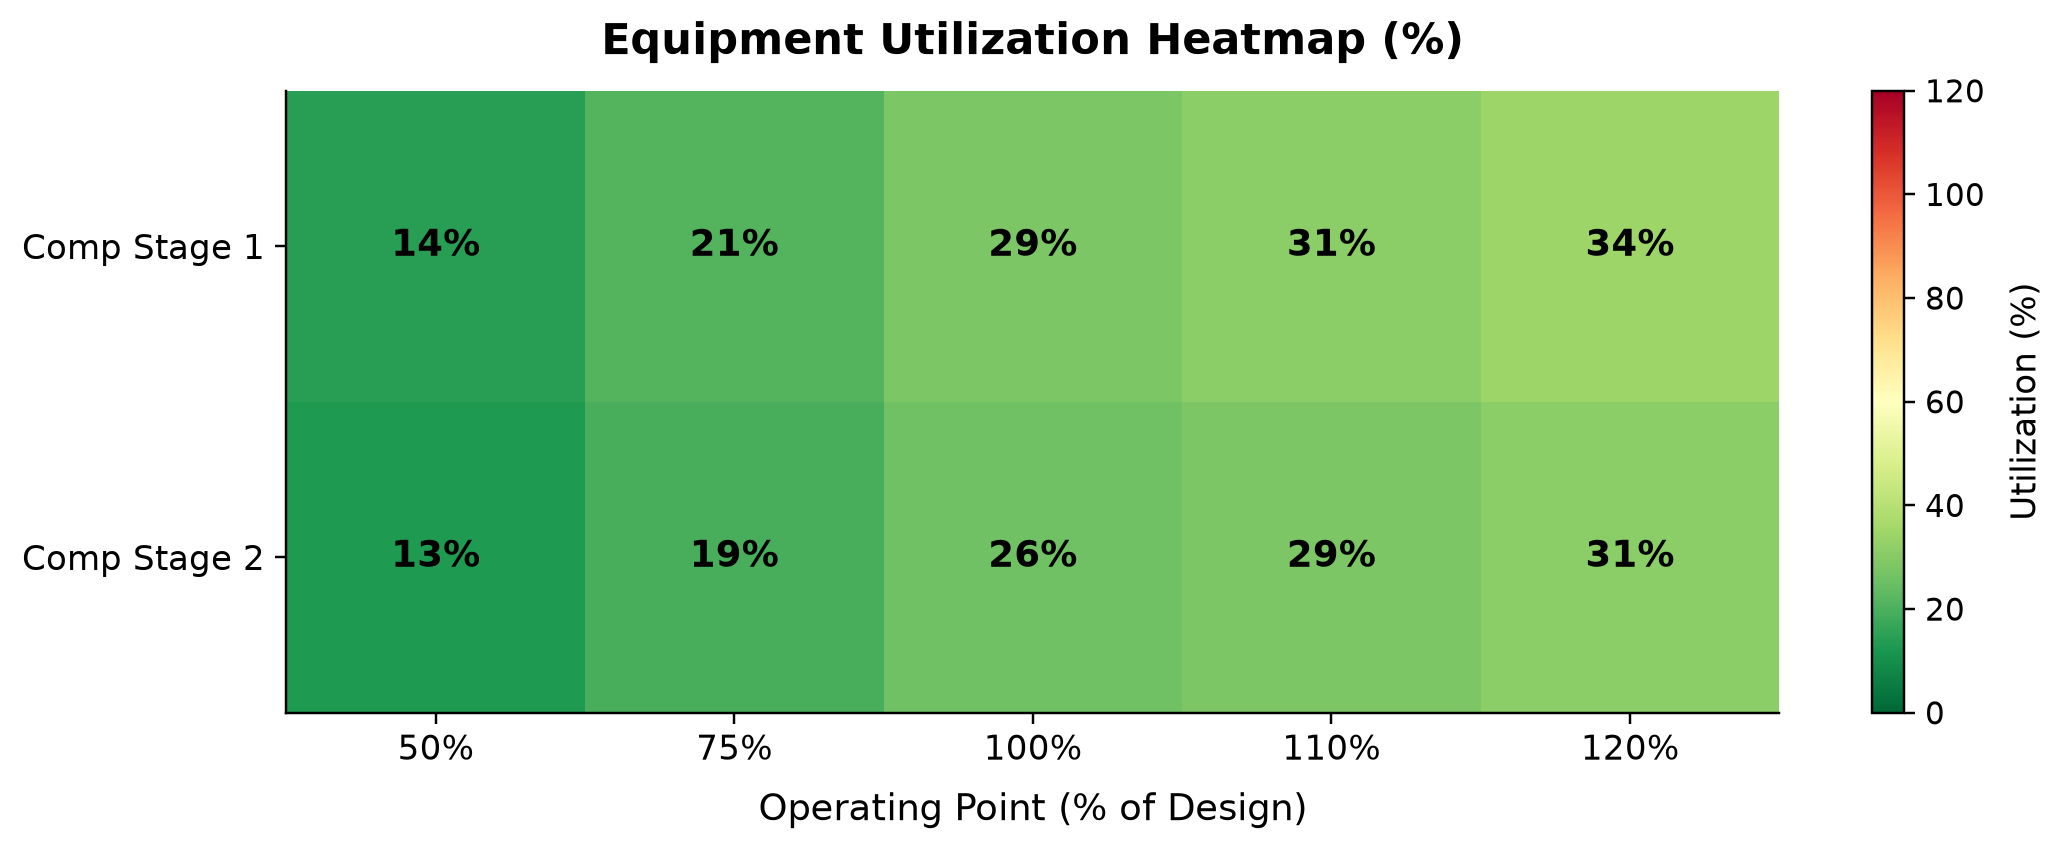

In [4]:
# --- Heatmap: Utilization matrix ---
fig, ax = plt.subplots(figsize=(10, 4))

im = ax.imshow(utilization_matrix * 100, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=120)
ax.set_xticks(range(len(operating_labels)))
ax.set_xticklabels(operating_labels, fontsize=11)
ax.set_yticks(range(len(equipment_names)))
ax.set_yticklabels(equipment_names, fontsize=11)
ax.set_xlabel('Operating Point (% of Design)', fontsize=12)
ax.set_title('Equipment Utilization Heatmap (%)', fontsize=14)

# Annotate cells
for i in range(len(equipment_names)):
    for j in range(len(operating_labels)):
        val = utilization_matrix[i, j] * 100
        color = 'white' if val > 80 else 'black'
        ax.text(j, i, f'{val:.0f}%', ha='center', va='center', fontsize=12, fontweight='bold', color=color)

cbar = plt.colorbar(im, ax=ax, label='Utilization (%)')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch26_utilization_heatmap.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ../figures/ch26_utilization_heatmap.png")


**Executed-figure discussion.** Across the five operating fractions and two compressor stages, power utilization spans 13.0–34.2 percent of the assumed 3500 and 4000 kW stage ratings.

Each heatmap cell divides simulated stage power by its stated assumed power rating. The color comparison identifies the more heavily loaded stage, even when both remain below their limits. Retain the absolute duties and ratings with the percentages so the available headroom can be checked.


## 25.3 Bottleneck Transition Analysis

We perform a fine sweep to find the exact rate at which the bottleneck transitions from one
equipment item to another.

Figure saved: ../figures/ch26_bottleneck_transition.png


ch26_utilization_monitoring.ipynb:cell8:42: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown


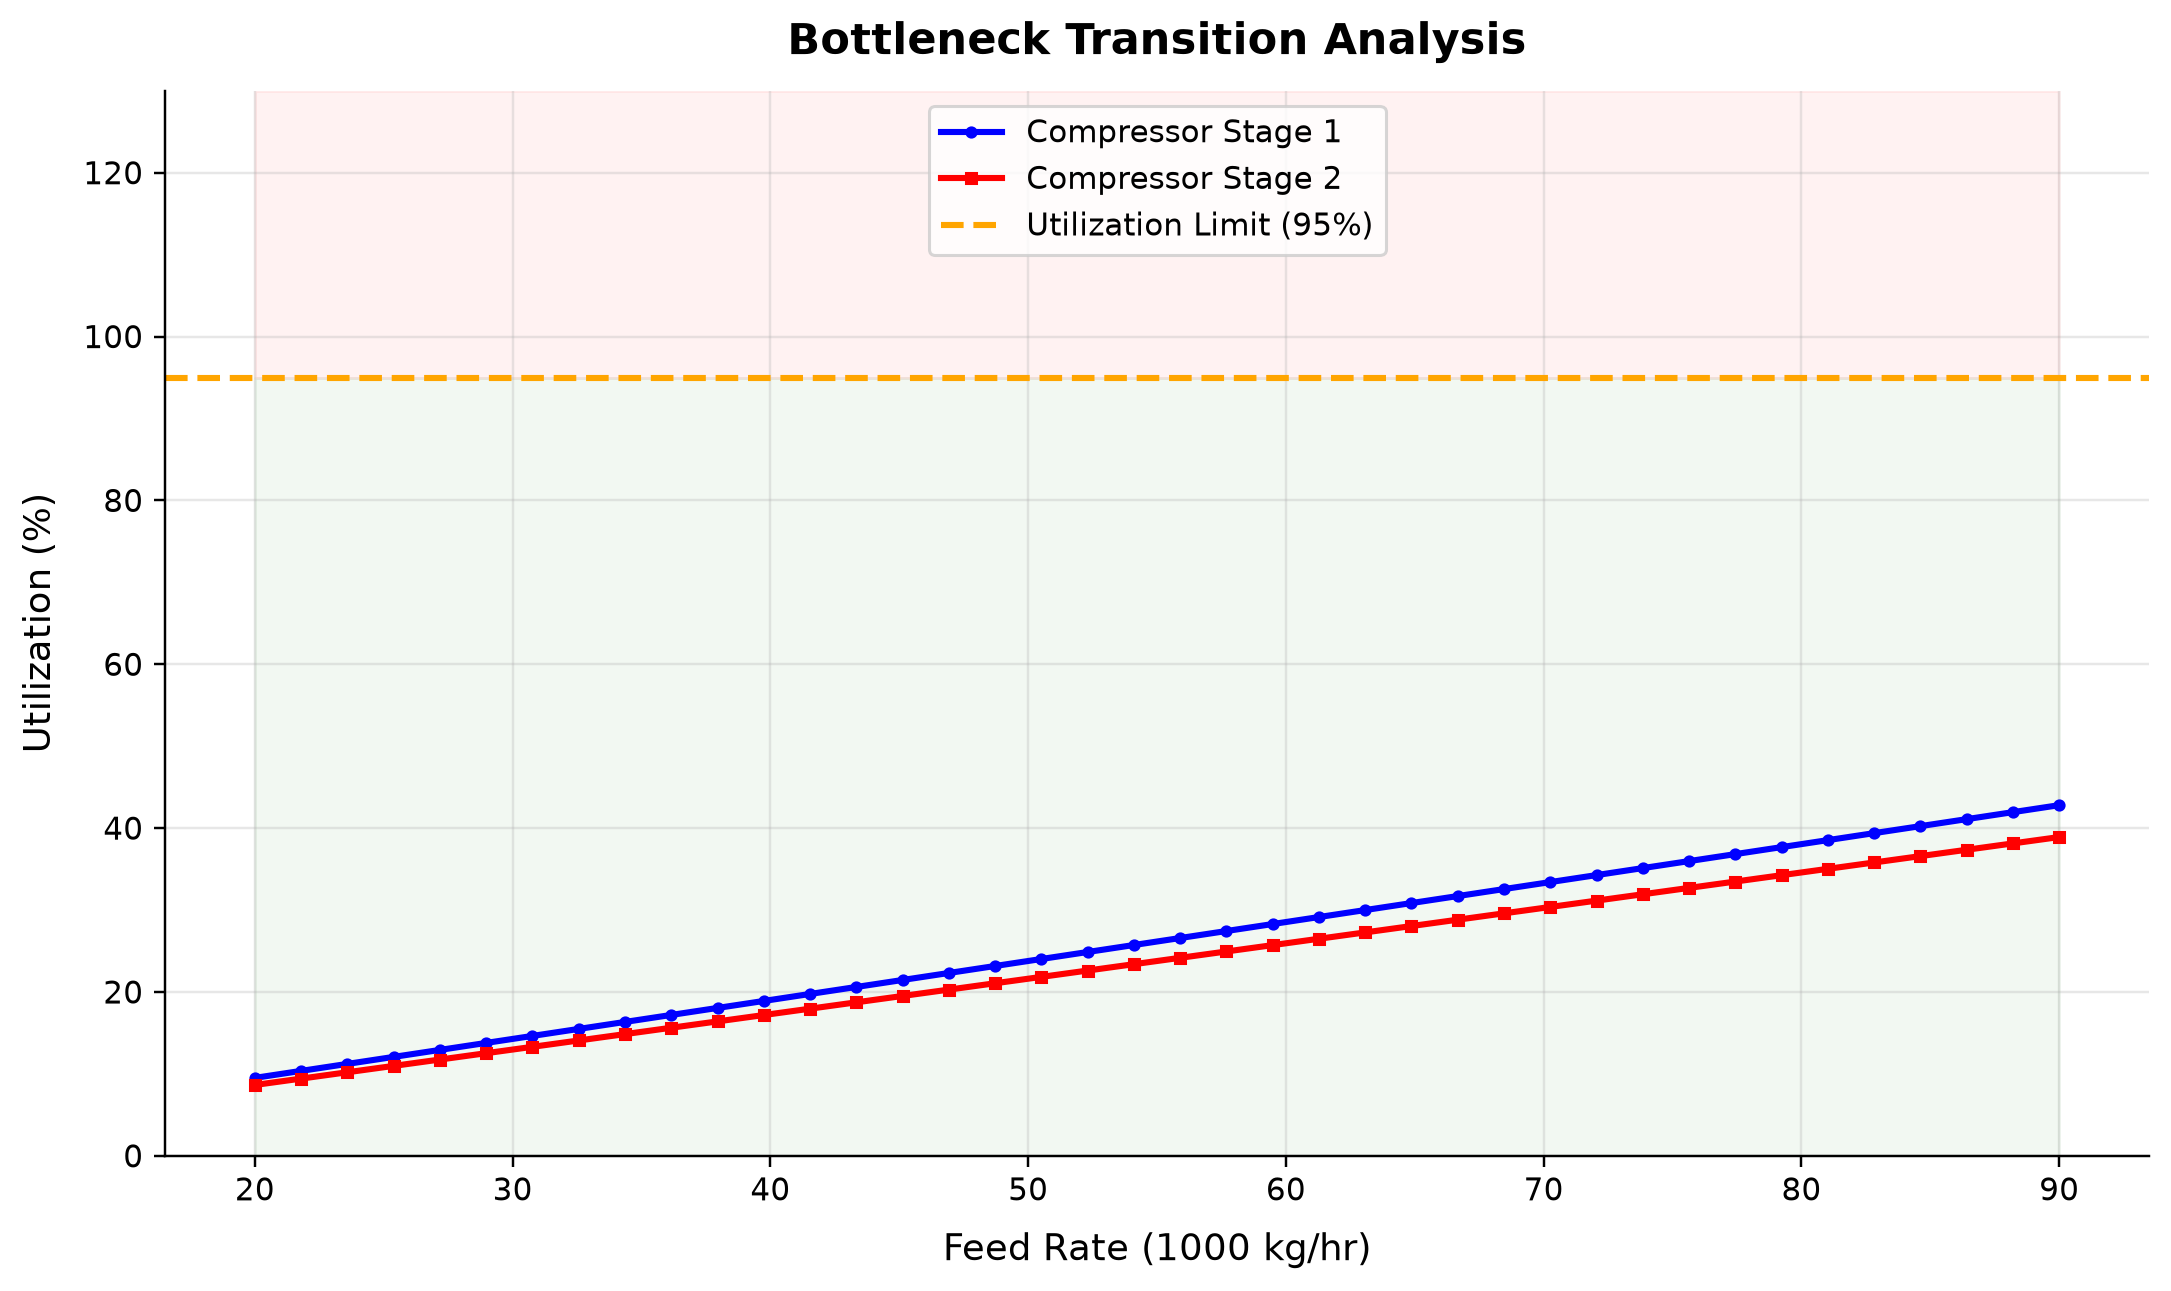

In [5]:
# --- Fine sweep for bottleneck transitions ---
fine_rates = np.linspace(20000, 90000, 40)
comp1_util = []
comp2_util = []

for rate in fine_rates:
    feed.setFlowRate(float(rate), "kg/hr")
    process.run()
    assert _physics.run(process, 'calculation_cell_8:process', candidate=False)
    comp1_util.append(comp1.getPower("kW") / 3500.0)
    comp2_util.append(comp2.getPower("kW") / 4000.0)

comp1_util = np.array(comp1_util)
comp2_util = np.array(comp2_util)

# Find bottleneck at each rate
bottleneck = ['Comp 1' if c1 > c2 else 'Comp 2' for c1, c2 in zip(comp1_util, comp2_util)]

# Reset
feed.setFlowRate(design_rate, "kg/hr")
process.run()
assert _physics.run(process, 'calculation_cell_8:process', candidate=False)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(fine_rates / 1000, comp1_util * 100, 'b-o', markersize=3, label='Compressor Stage 1')
ax.plot(fine_rates / 1000, comp2_util * 100, 'r-s', markersize=3, label='Compressor Stage 2')
ax.axhline(y=95, color='orange', linestyle='--', linewidth=2, label='Utilization Limit (95%)')

ax.fill_between(fine_rates / 1000, 0, 95, alpha=0.05, color='green')
ax.fill_between(fine_rates / 1000, 95, 130, alpha=0.05, color='red')

ax.set_xlabel('Feed Rate (1000 kg/hr)', fontsize=12)
ax.set_ylabel('Utilization (%)', fontsize=12)
ax.set_title('Bottleneck Transition Analysis', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 130)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'ch26_bottleneck_transition.png', dpi=220, bbox_inches="tight")
plt.show()
print("Figure saved: ../figures/ch26_bottleneck_transition.png")


**Executed-figure discussion.** Compressor Stage 1: utilization spans 9.511–42.8 % across the plotted cases. Compressor Stage 2: utilization spans 8.646–38.91 % across the plotted cases.

For this fixed-composition, fixed-pressure case, both compression duties scale nearly linearly with throughput. Stage 1 remains the more highly utilized stage over the plotted range; this particular sweep does not demonstrate a bottleneck switch. Add composition or equipment-state changes if the purpose is to test migration of the limiting unit.


## 25.4 Summary

Utilization monitoring reveals:

1. **Equipment utilization scales non-linearly** with feed rate due to thermodynamic effects
2. **Bottleneck transitions** can occur as operating conditions change
3. **Heatmap visualization** provides an immediate overview of capacity status
4. **Operating margin** can be quantified for each equipment item at any operating point

For real-time operations, these calculations can be embedded in digital twin applications
to provide continuous capacity monitoring and early warning of constraint violations.

## Numerical output and figure provenance
The following table is extracted from the plotted numerical data. Each saved figure has an adjacent CSV and JSON record; missing points remain visible and are not replaced by interpolated results. Extrema summarize the sampled operating envelope, and are not independent validation of the model.


In [6]:
figure_results = export_figure_summary(NOTEBOOK_PATH)
print(figure_results.to_string(index=False, float_format=lambda value: f'{value:.6g}'))


                        Figure  Panel                  Series   Output / unit  Minimum  Maximum  Finite points  Missing points
ch26_bottleneck_transition.png      1      Compressor Stage 1 Utilization (%)  9.51116  42.8002             40               0
ch26_bottleneck_transition.png      1      Compressor Stage 2 Utilization (%)  8.64612  38.9075             40               0
ch26_bottleneck_transition.png      1 Utilization Limit (95%) Utilization (%)       95       95              2               0


## Physical verification and its limits
The assertions above test the calculated states and steady-state conservation laws. Rejected operating candidates remain excluded; they do not become synthetic outputs. The chapter-specific checks below state the applicable limits. Independent reference-fluid and analytic benchmarks are recorded separately in `verification/scientific_revision/benchmark_results.json`. Passing these checks does not establish field calibration or an installed equipment rating.


In [7]:
from chapter_specific_checks import validate_chapter
assert validate_chapter(_physics, globals())
assert _physics.finish()


Physics verification: 576 distinct checks, 9612 evaluations; 0 rejected nonphysical candidates.


## Physical verification and scope

Power utilization ratios. Overloads are deliberately plotted; a positive value is not an acceptance decision.

The final code cell checks the computed cases against explicit physical, analytical or constraint criteria. A passed conservation check establishes internal consistency; it does not establish field accuracy. Independent reference values, actual model results, units, acceptance tolerances and source provenance are retained in the [benchmark notebook](../../../verification/scientific_revision/36_benchmark_validation.ipynb), [benchmark results](../../../verification/scientific_revision/benchmark_results.json) and [chapter validation ledger](../../../verification/scientific_revision/notebook_physics_review.md).
